#  EDA: `history`


**Descripción:** Historial de **logros desbloqueados** por usuarios. Cada fila registra el momento exacto en que un jugador desbloqueó un logro específico. Este archivo **no contiene horas de sesión ni tiempo de juego** esa variable no existe en el dataset.

| Columna | Tipo | Descripción |
|---|---|---|
| `playerid` | int | ID del jugador (Steam ID) |
| `achievementid` | str | ID del logro: `{gameid}_{codigo}` |
| `date_acquired` | datetime | Timestamp exacto de desbloqueo |

---

##  Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DARK_BG = '#0e1117'
CARD_BG = '#1a1f2e'
ACCENT1 = '#4f86f7'
ACCENT2 = '#7ee8a2'
ACCENT3 = '#ff6b6b'
ACCENT4 = '#ffd166'
TEXT    = '#e0e6f0'
MUTED   = '#8892a4'

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': MUTED,     'axes.labelcolor': TEXT,
    'xtick.color': MUTED,        'ytick.color': MUTED,
    'text.color': TEXT,          'grid.color': '#2d3348',
    'grid.alpha': 0.6,           'font.family': 'DejaVu Sans',
    'font.size': 11,
})

def title_ax(ax, txt, sub=None):
    ax.set_title(txt, fontsize=13, fontweight='bold', color=TEXT, pad=8)
    if sub:
        ax.text(0.5, 1.02, sub, transform=ax.transAxes,
                ha='center', fontsize=9, color=MUTED)

##  Carga y exploración inicial

In [2]:
df_raw = pd.read_csv('Datos/history.csv') 
print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
df_raw.head(5)

Shape: 10,693,879 filas × 3 columnas


,playerid,achievementid,date_acquired
0,76561198220441373,403640_ACH_1,2019-12-18 15:33:43
1,76561198220441373,403640_ACH_2,2019-12-18 23:49:51
2,76561198220441373,403640_ACH_3,2019-12-19 23:05:07
3,76561198220441373,403640_ACH_4,2019-12-24 05:50:49
4,76561198220441373,403640_ACH_5,2023-04-19 22:39:36


In [3]:
print(df_raw.dtypes)
print()
df_raw.describe(include='all')

playerid          int64
achievementid    object
date_acquired    object
dtype: object



,playerid,achievementid,date_acquired
count,1.069388e+07,10693879,10693879
unique,NaN,886988,4504769
top,NaN,730_PLAY_CS2,2023-01-30 16:04:55
freq,NaN,2915,10979
mean,7.656120e+16,NaN,NaN
std,3.325915e+08,NaN,NaN
min,7.656120e+16,NaN,NaN
25%,7.656120e+16,NaN,NaN
50%,7.656120e+16,NaN,NaN
75%,7.656120e+16,NaN,NaN


---
##  Análisis y tratamiento de valores faltantes

### Diagnóstico 

In [4]:
missing = df_raw.isnull() | (df_raw.apply(lambda col: col.astype(str).str.strip() == ''))
miss_pct = (missing.mean() * 100).round(4)
miss_cnt = missing.sum()

print("Faltantes por columna:")
display(pd.DataFrame({'count': miss_cnt, 'pct (%)': miss_pct}).sort_values('pct (%)', ascending=False))

Faltantes por columna:


,count,pct (%)
playerid,0,0.0
achievementid,0,0.0
date_acquired,0,0.0


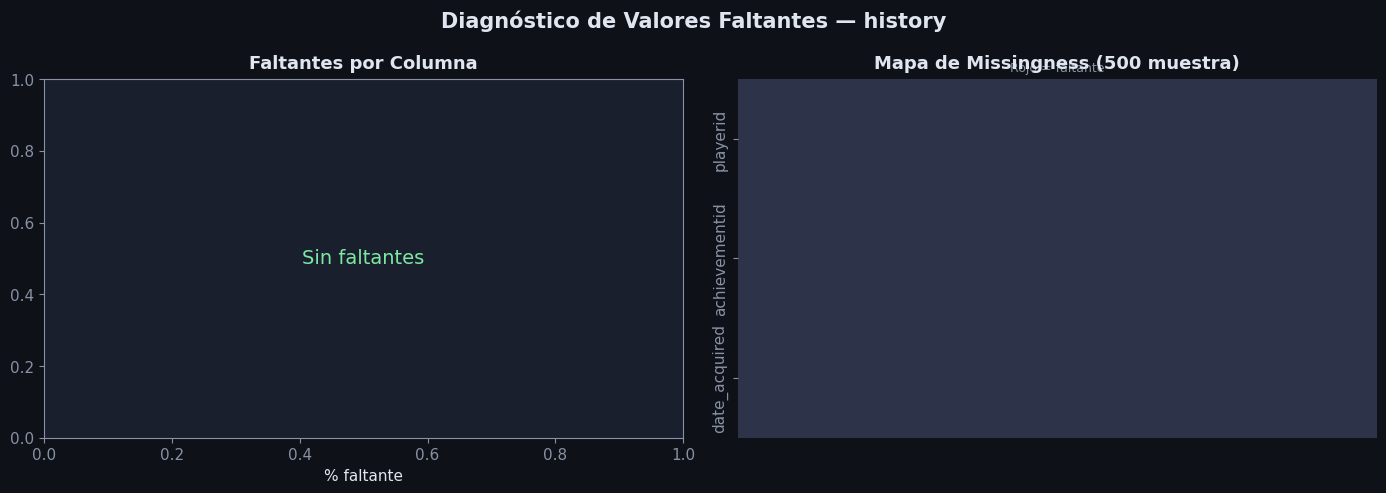

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Diagnóstico de Valores Faltantes — history', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
cols_m = miss_pct[miss_pct > 0].sort_values()
if len(cols_m) > 0:
    colors_m = [ACCENT3 if v > 30 else ACCENT4 if v > 5 else ACCENT1 for v in cols_m.values]
    bars = ax.barh(cols_m.index, cols_m.values, color=colors_m)
    for bar, val in zip(bars, cols_m.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}%', va='center', color=TEXT, fontsize=11)
    ax.set_xlim(0, max(cols_m.values) * 2)
else:
    ax.text(0.5, 0.5, 'Sin faltantes', ha='center', va='center',
            transform=ax.transAxes, fontsize=14, color=ACCENT2)
ax.set_xlabel('% faltante')
title_ax(ax, 'Faltantes por Columna')

ax = axes[1]
sample = df_raw.sample(min(500, len(df_raw)), random_state=42)
miss_m = sample.isnull() | (sample.apply(lambda col: col.astype(str).str.strip() == ''))
sns.heatmap(miss_m.T, ax=ax, cbar=False,
            cmap=['#2d3348', ACCENT3], yticklabels=True, xticklabels=False)
title_ax(ax, 'Mapa de Missingness (500 muestra)', 'Rojo = faltante')

plt.tight_layout()
plt.show()

In [6]:
df = df_raw.copy()

df['date_acquired'] = pd.to_datetime(df['date_acquired'], errors='coerce')
n_bad_dates = df['date_acquired'].isna().sum()
print(f"Fechas no parseables (eliminadas): {n_bad_dates:,}")
df = df[df['date_acquired'].notna()].reset_index(drop=True)

df['gameid'] = df['achievementid'].str.split('_').str[0].astype(int, errors='ignore')

df['year']    = df['date_acquired'].dt.year
df['month']   = df['date_acquired'].dt.month
df['hour']    = df['date_acquired'].dt.hour
df['weekday'] = df['date_acquired'].dt.dayofweek  

print(f"\nDataset final: {len(df):,} filas")
print(f"Rango temporal: {df['date_acquired'].min()} → {df['date_acquired'].max()}")
df.head(3)

Fechas no parseables (eliminadas): 0

Dataset final: 10,693,879 filas
Rango temporal: 2008-09-13 01:37:54 → 2024-12-15 19:42:05


,playerid,achievementid,date_acquired,gameid,year,month,hour,weekday
0,76561198220441373,403640_ACH_1,2019-12-18 15:33:43,403640,2019,12,15,2
1,76561198220441373,403640_ACH_2,2019-12-18 23:49:51,403640,2019,12,23,2
2,76561198220441373,403640_ACH_3,2019-12-19 23:05:07,403640,2019,12,23,3


---
##  Validación de integridad

###  Hallazgos 
- No hay duplicados en el par `(playerid, achievementid)` cada logro se desbloquea una sola vez por jugador, lo que confirma la integridad de la clave compuesta.
- El `gameid` extraído del `achievementid` es consistente y permite cruzar con la tabla `achievements`.


In [7]:
dups = df.duplicated(['playerid', 'achievementid']).sum()
print(f"Duplicados (playerid, achievementid) : {dups:,}")
print(f"Jugadores únicos                     : {df['playerid'].nunique():,}")
print(f"Achievements únicos                  : {df['achievementid'].nunique():,}")
print(f"Juegos únicos                        : {df['gameid'].nunique():,}")
print(f"Pares únicos (jugador, juego)         : {df.groupby(['playerid','gameid']).ngroups:,}")
print(f"Rango temporal                       : {df['date_acquired'].min().date()} → {df['date_acquired'].max().date()}")

Duplicados (playerid, achievementid) : 0
Jugadores únicos                     : 4,838
Achievements únicos                  : 886,988
Juegos únicos                        : 13,420
Pares únicos (jugador, juego)         : 276,036
Rango temporal                       : 2008-09-13 → 2024-12-15


---
##  Distribución de Actividad por Jugador

### Hallazgos

- La distribución de logros por jugador es **fuertemente sesgada a la derecha**: la mediana es 455 logros, mientras que el máximo alcanza 545,949 logros.
- Un pequeño grupo de jugadores presenta valores extremadamente altos, con varios superando los 200,000 logros, lo que sugiere posibles perfiles especializados en coleccionar logros o interactuar con juegos de achievement spam.
- Usando el criterio IQR (Q3 + 1.5×IQR = 3,455) se identifican 524 jugadores outliers en esta muestra.
- La mayoría de los jugadores acumula relativamente pocos logros: el 75% tiene menos de 1,462 logros y el 90% menos de 3,677.


In [8]:
per_player = df.groupby('playerid').size().rename('n_achievements').sort_values(ascending=False)

Q1_p, Q3_p = per_player.quantile(0.25), per_player.quantile(0.75)
IQR_p      = Q3_p - Q1_p
upper_p    = Q3_p + 1.5 * IQR_p

print("Estadísticas de logros por jugador:")
print(per_player.describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print(f"\nUmbral IQR (outlier): {upper_p:.0f} logros")
print(f"Jugadores sobre umbral IQR: {(per_player > upper_p).sum():,}")
print()
print("Top 10 jugadores por logros:")
display(per_player.head(10).to_frame())

Estadísticas de logros por jugador:
count      4838.000000
mean       2210.392518
std       13161.102483
min           1.000000
25%         133.000000
50%         455.000000
75%        1461.750000
90%        3676.800000
95%        6278.350000
99%       24909.920000
max      545949.000000
Name: n_achievements, dtype: float64

Umbral IQR (outlier): 3455 logros
Jugadores sobre umbral IQR: 524

Top 10 jugadores por logros:


,n_achievements
playerid,
76561198298591193,545949
76561197987596512,300117
76561197987340453,264852
76561198222963584,259215
76561198099241446,230179
76561198307860947,208658
76561198280871241,204901
76561198180488782,154020
76561198206518029,145094


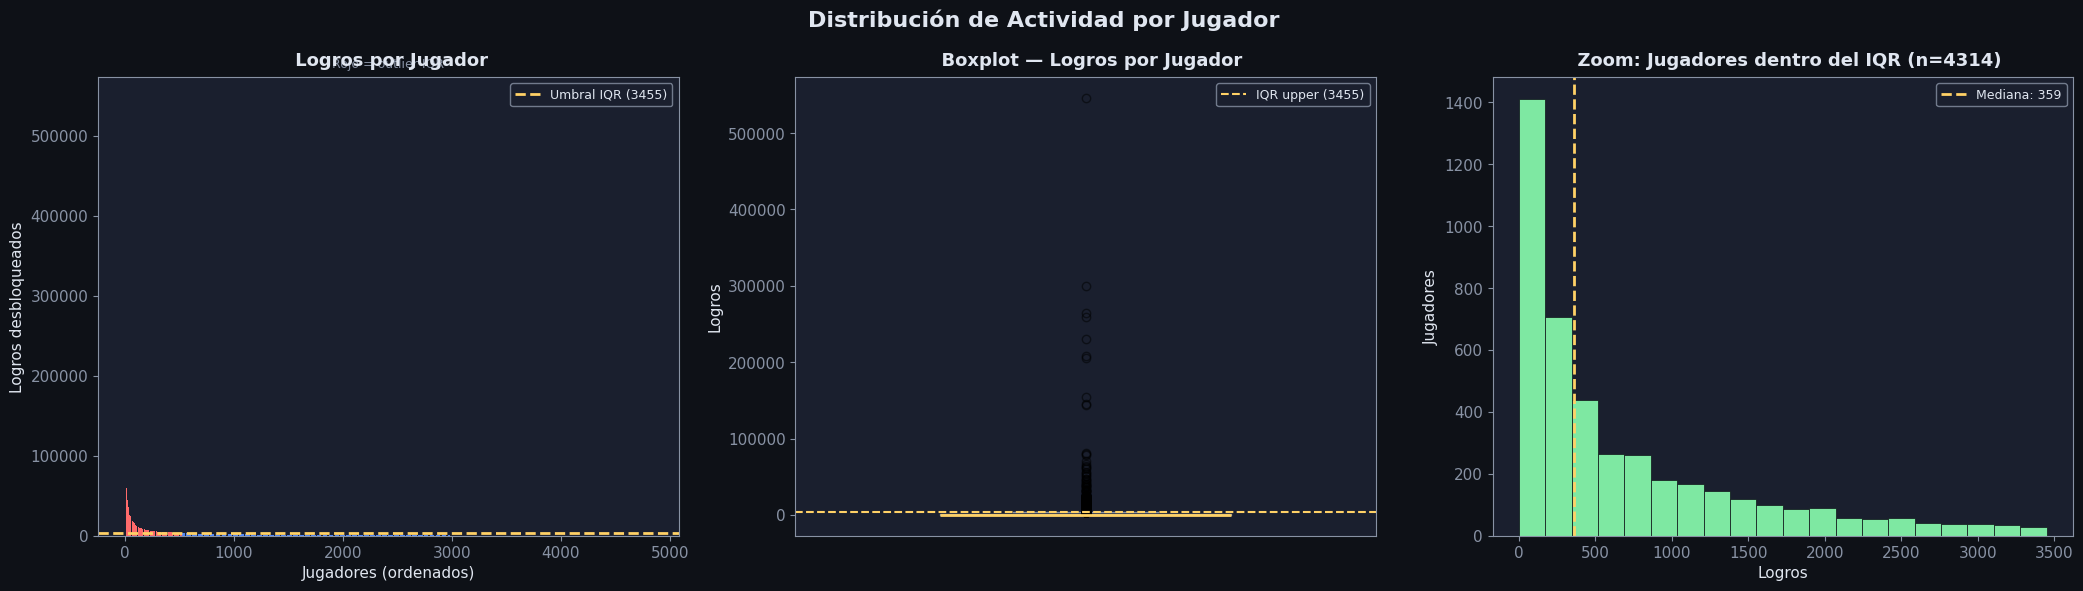

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución de Actividad por Jugador', fontsize=16, fontweight='bold', color=TEXT)

ax = axes[0]
colors_p = [ACCENT3 if v > upper_p else ACCENT1 for v in per_player.values]
ax.bar(range(len(per_player)), per_player.values, color=colors_p)
ax.axhline(upper_p, color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Umbral IQR ({upper_p:.0f})')
ax.set_xlabel('Jugadores (ordenados)'); ax.set_ylabel('Logros desbloqueados')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, ' Logros por Jugador', 'Rojo = outlier IQR')

ax = axes[1]
bp = ax.boxplot(per_player.values, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor=ACCENT1, color=MUTED),
                medianprops=dict(color=ACCENT4, linewidth=2),
                whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
                flierprops=dict(marker='o', color=ACCENT3, alpha=0.5, markersize=6))
ax.axhline(upper_p, color=ACCENT4, linewidth=1.5, linestyle='--',
           label=f'IQR upper ({upper_p:.0f})')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_ylabel('Logros'); ax.set_xticks([])
title_ax(ax, '  Boxplot — Logros por Jugador')

ax = axes[2]
per_player_zoom = per_player[per_player <= upper_p]
ax.hist(per_player_zoom.values, bins=20, color=ACCENT2, edgecolor=DARK_BG, linewidth=0.5)
ax.axvline(per_player_zoom.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {per_player_zoom.median():.0f}')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros'); ax.set_ylabel('Jugadores')
title_ax(ax, f'  Zoom: Jugadores dentro del IQR (n={len(per_player_zoom)})')

plt.tight_layout()
plt.show()

---
##  Análisis Temporal

###  Hallazgos

- Se observa un spike extremadamente alto el 16 de abril de 2018, con 122,608 logros desbloqueados en un solo día, provenientes de 248 jugadores y 160 juegos. Este valor es muy superior a la actividad típica diaria, lo que sugiere un evento atípico en el dataset, posiblemente relacionado con juegos con grandes cantidades de logros o actividad intensiva de algunos usuarios.
- A nivel anual, la actividad de desbloqueo de logros crece de forma sostenida entre 2009 y 2017, alcanzando un máximo en 2018 (2.41M logros). Después de ese punto, la actividad se mantiene relativamente alta entre 2019 y 2022, con una ligera disminución en 2023–2024.
- La distribución por hora del día muestra mayor actividad en la tarde y noche (18:00–24:00), consistente con patrones de uso recreativo donde los jugadores tienden a jugar después de sus actividades diarias.
- La actividad no se concentra en los fines de semana. El miércoles presenta el mayor número de logros desbloqueados, lo que indica que el patrón de actividad semanal no sigue necesariamente el comportamiento recreativo esperado de mayor uso en sábado y domingo.




In [10]:
by_year  = df.groupby('year').size().rename('n_achievements')
by_month = df.groupby('month').size().rename('n_achievements')
by_hour  = df.groupby('hour').size().rename('n_achievements')
by_dow   = df.groupby('weekday').size().rename('n_achievements')

print("Logros por año:")
print(by_year.to_string())
print()

spike_day = df[df['date_acquired'].dt.date == pd.Timestamp('2018-04-16').date()]
print(f"Spike 2018-04-16: {len(spike_day):,} logros, {spike_day['playerid'].nunique()} jugadores, {spike_day['gameid'].nunique()} juegos")

Logros por año:
year
2008         33
2009       3032
2010      17307
2011      38633
2012      53013
2013      93467
2014     150727
2015     231704
2016     307072
2017     841550
2018    2410833
2019    1328008
2020    1163315
2021    1299340
2022    1070679
2023     789196
2024     895970

Spike 2018-04-16: 122,608 logros, 248 jugadores, 160 juegos


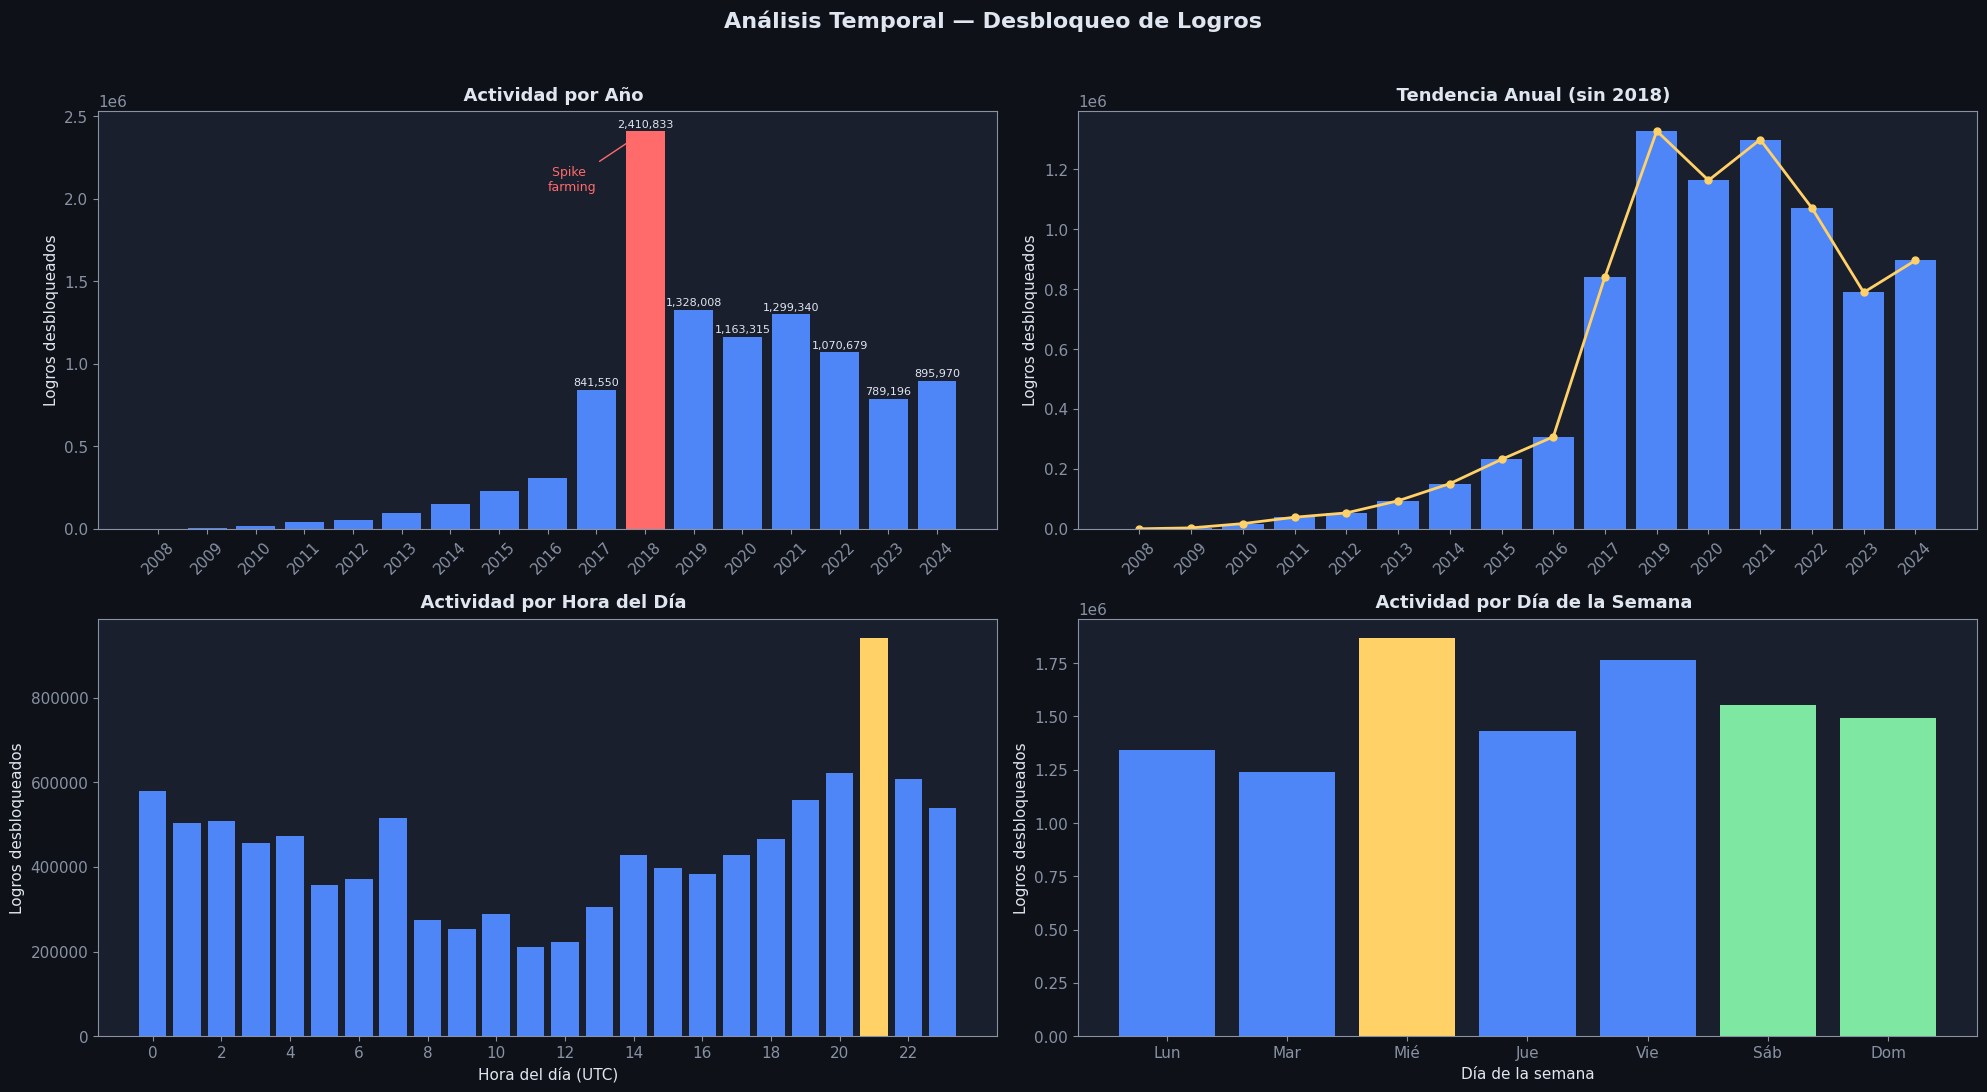

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(20, 11))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Análisis Temporal — Desbloqueo de Logros', fontsize=16, fontweight='bold', color=TEXT, y=0.99)

dow_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

ax = axes[0, 0]
colors_y = [ACCENT3 if y == 2018 else ACCENT1 for y in by_year.index]
bars = ax.bar(by_year.index.astype(str), by_year.values, color=colors_y)
for bar, val in zip(bars, by_year.values):
    if val > by_year.mean():
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + by_year.max()*0.01,
                f'{val:,}', ha='center', fontsize=8, color=TEXT)
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Logros desbloqueados')
ax.annotate(' Spike\nfarming', xy=(by_year.index.tolist().index(2018), by_year[2018]),
            xytext=(by_year.index.tolist().index(2018) - 2, by_year[2018] * 0.85),
            arrowprops=dict(arrowstyle='->', color=ACCENT3), color=ACCENT3, fontsize=9)
title_ax(ax, '  Actividad por Año')

ax = axes[0, 1]
by_year_no_spike = by_year.drop(2018, errors='ignore')
ax.bar(by_year_no_spike.index.astype(str), by_year_no_spike.values, color=ACCENT1)
ax.plot(range(len(by_year_no_spike)), by_year_no_spike.values,
        color=ACCENT4, linewidth=2, marker='o', markersize=5)
ax.tick_params(axis='x', rotation=45)
ax.set_ylabel('Logros desbloqueados')
title_ax(ax, '  Tendencia Anual (sin 2018)')

ax = axes[1, 0]
peak_hour = by_hour.idxmax()
colors_h = [ACCENT4 if h == peak_hour else ACCENT1 for h in by_hour.index]
ax.bar(by_hour.index, by_hour.values, color=colors_h)
ax.set_xlabel('Hora del día (UTC)'); ax.set_ylabel('Logros desbloqueados')
ax.set_xticks(range(0, 24, 2))
title_ax(ax, '  Actividad por Hora del Día')

ax = axes[1, 1]
peak_dow = by_dow.idxmax()
colors_d = [ACCENT4 if d == peak_dow else ACCENT2 if d >= 5 else ACCENT1 for d in by_dow.index]
ax.bar([dow_labels[d] for d in by_dow.index], by_dow.values, color=colors_d)
ax.set_xlabel('Día de la semana'); ax.set_ylabel('Logros desbloqueados')
title_ax(ax, '  Actividad por Día de la Semana')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Distribución de Logros por Juego y por Par (Jugador, Juego)

### Hallazgos

- La distribución del número total de logros desbloqueados por juego (sumando todos los jugadores) es fuertemente sesgada a la derecha. La mediana es 32 desbloqueos, mientras que algunos juegos superan los 300,000 desbloqueos, lo que refleja juegos muy populares o con muchos jugadores activos.
- Usando el criterio IQR (umbral = 289) se identifican 2,026 juegos outliers, es decir, títulos con una cantidad de desbloqueos significativamente mayor que el resto.
- A nivel de par (jugador, juego) que representa cuántos logros desbloquea un jugador dentro de un juego específico la mediana es 9 logros, el percentil 75 es 21, y el percentil 95 es 66.
- Esta variable (`n_ach_pair`) es la feature central para el modelo de regresión, ya que captura el nivel de progreso de un jugador dentro de cada juego.


In [12]:
per_game    = df.groupby('gameid').size().rename('n_unlocked')
per_pg      = df.groupby(['playerid', 'gameid']).size().rename('n_ach_pair')

Q1_g, Q3_g = per_game.quantile(0.25), per_game.quantile(0.75)
IQR_g      = Q3_g - Q1_g
upper_g    = Q3_g + 1.5 * IQR_g

Q1_pg, Q3_pg = per_pg.quantile(0.25), per_pg.quantile(0.75)
IQR_pg       = Q3_pg - Q1_pg
upper_pg     = Q3_pg + 1.5 * IQR_pg

print("Logros desbloqueados por juego (total de todos los jugadores):")
print(per_game.describe(percentiles=[.25,.5,.75,.90,.95,.99]))
print(f"\nUmbral IQR (juego): {upper_g:.0f}")
print(f"Juegos outlier IQR: {(per_game > upper_g).sum():,}")
print()
print("Logros por par (jugador, juego) —  feature clave para regresión:")
print(per_pg.describe(percentiles=[.25,.5,.75,.90,.95,.99]))
print(f"\nUmbral IQR (par jugador-juego): {upper_pg:.0f}")
print(f"Pares outlier IQR: {(per_pg > upper_pg).sum():,} ({(per_pg > upper_pg).mean()*100:.2f}%)")

Logros desbloqueados por juego (total de todos los jugadores):
count     13420.000000
mean        796.861326
std        7079.627162
min           1.000000
25%           9.000000
50%          32.000000
75%         121.000000
90%         560.000000
95%        1549.250000
99%       16217.670000
max      362752.000000
Name: n_unlocked, dtype: float64

Umbral IQR (juego): 289
Juegos outlier IQR: 2,026

Logros por par (jugador, juego) —  feature clave para regresión:
count    276036.000000
mean         38.740885
std         281.938489
min           1.000000
25%           3.000000
50%           9.000000
75%          21.000000
90%          42.000000
95%          66.000000
99%         352.650000
max       10979.000000
Name: n_ach_pair, dtype: float64

Umbral IQR (par jugador-juego): 48
Pares outlier IQR: 22,272 (8.07%)


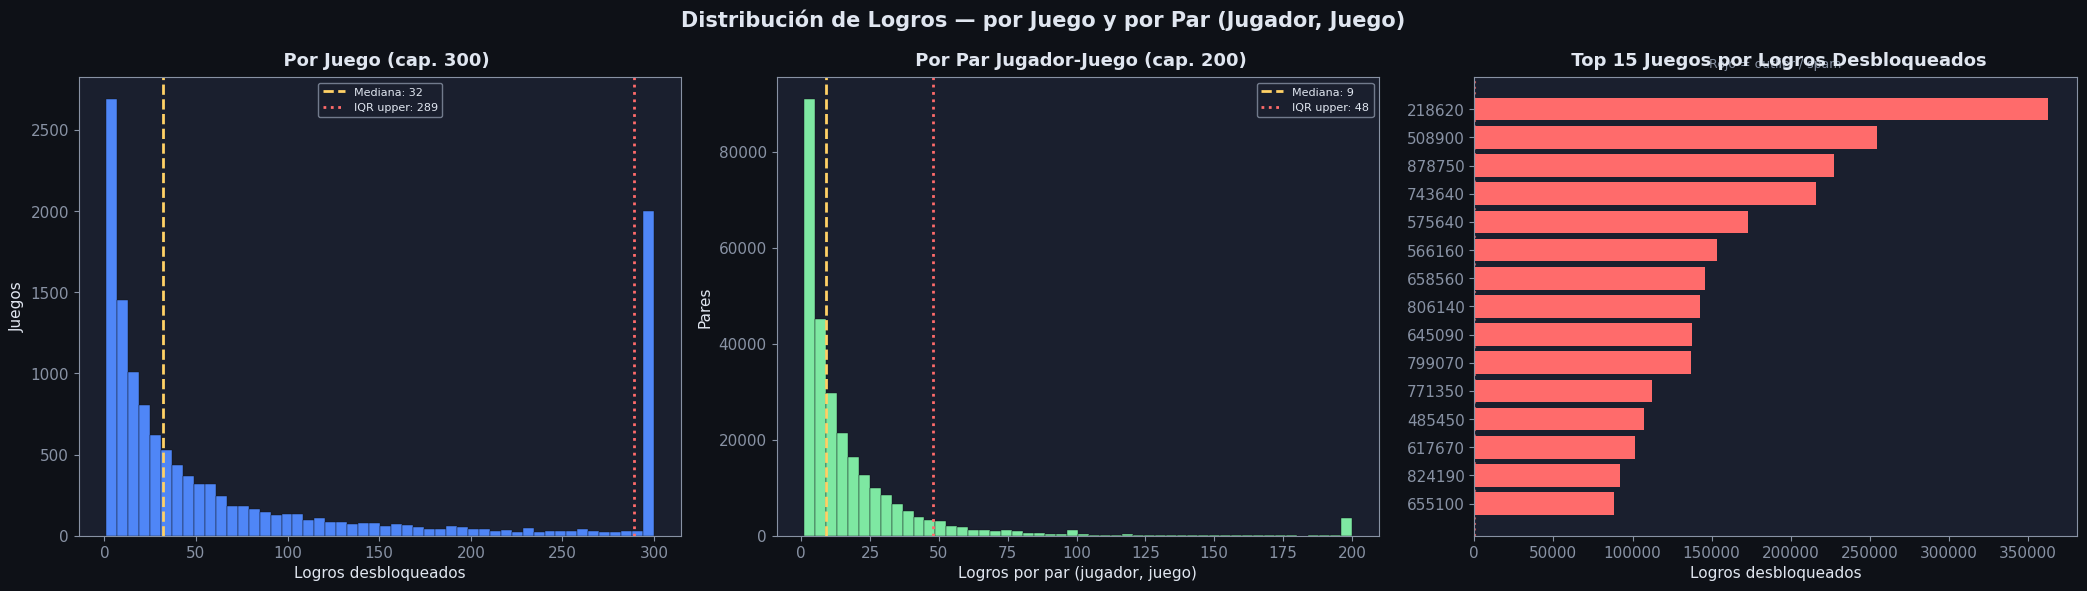

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Distribución de Logros — por Juego y por Par (Jugador, Juego)', fontsize=15,
             fontweight='bold', color=TEXT)

ax = axes[0]
ax.hist(per_game.clip(upper=300), bins=50, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3)
ax.axvline(per_game.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {per_game.median():.0f}')
ax.axvline(upper_g, color=ACCENT3, linewidth=2, linestyle=':',
           label=f'IQR upper: {upper_g:.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros desbloqueados'); ax.set_ylabel('Juegos')
title_ax(ax, '  Por Juego (cap. 300)')

ax = axes[1]
ax.hist(per_pg.clip(upper=200), bins=50, color=ACCENT2, edgecolor=DARK_BG, linewidth=0.3)
ax.axvline(per_pg.median(), color=ACCENT4, linewidth=2, linestyle='--',
           label=f'Mediana: {per_pg.median():.0f}')
ax.axvline(upper_pg, color=ACCENT3, linewidth=2, linestyle=':',
           label=f'IQR upper: {upper_pg:.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por par (jugador, juego)'); ax.set_ylabel('Pares')
title_ax(ax, ' Por Par Jugador-Juego (cap. 200)')

ax = axes[2]
top15_g = per_game.sort_values(ascending=False).head(15)
colors_t = [ACCENT3 if v >= 5000 else ACCENT4 if v > upper_g else ACCENT1 for v in top15_g.values]
ax.barh(top15_g.index.astype(str)[::-1], top15_g.values[::-1], color=colors_t[::-1])
ax.axvline(upper_g, color=ACCENT3, linewidth=1.5, linestyle=':', alpha=0.7)
ax.set_xlabel('Logros desbloqueados')
title_ax(ax, ' Top 15 Juegos por Logros Desbloqueados', 'Rojo = outlier / spam')

plt.tight_layout()
plt.show()

---
## Outliers: Velocidad de Desbloqueo (Achievement Farming)

###  Hallazgos
- El 57.3% de los logros de la muestra tienen un delta temporal de 0 segundos respecto al logro anterior en el mismo juego. Esto sugiere desbloqueos extremadamente rápidos que difícilmente corresponden a juego normal.

- Si se incluyen también los logros desbloqueados entre 1 y 60 segundos, el total potencialmente asociado con achievement farming asciende a 68.8% de los logros.

- Un evento anómalo ocurre el 16 de abril de 2018, con más de 120,000 logros desbloqueados en un solo día por 248 jugadores en 160 juegos, lo que contribuye significativamente a los picos observados en velocidad de desbloqueo.

- Se definen dos categorías de velocidad extrema:
  - **`instant`**: delta = 0 segundos entre logros consecutivos en el mismo juego.
  - **`ultra_fast`**: delta entre 1 y 60 segundos, posible farming automatizado menos evidente.


| Opción | Descripción | Cuándo usar |
|---|---|---|
| **A — Eliminar** | Remover todas las filas donde el par `(playerid, gameid)` tenga >X% de logros instant | Análisis de comportamiento real de jugadores |
| **B — Etiquetar** | Agregar flag `is_farming` sin eliminar | Cuando se quiere comparar comportamiento farming vs orgánico |
| **C — Separar dataset** | Crear `df_clean` (sin farming) y `df_full` | Permite correr modelos en ambos y comparar |



In [14]:
df_sorted = df.sort_values(['playerid', 'gameid', 'date_acquired']).copy()
df_sorted['prev_date'] = df_sorted.groupby(['playerid', 'gameid'])['date_acquired'].shift(1)
df_sorted['delta_sec'] = (df_sorted['date_acquired'] - df_sorted['prev_date']).dt.total_seconds()


df_sorted['is_instant']    = df_sorted['delta_sec'] == 0
df_sorted['is_ultra_fast'] = (df_sorted['delta_sec'] > 0) & (df_sorted['delta_sec'] <= 60)
df_sorted['is_farming']    = df_sorted['is_instant'] | df_sorted['is_ultra_fast']

n_instant    = df_sorted['is_instant'].sum()
n_ultra_fast = df_sorted['is_ultra_fast'].sum()
n_farming    = df_sorted['is_farming'].sum()
n_total      = len(df_sorted)

print(f"Logros con delta = 0s (instant)    : {n_instant:,}  ({n_instant/n_total*100:.1f}%)")
print(f"Logros con delta 1–60s (ultra fast): {n_ultra_fast:,}  ({n_ultra_fast/n_total*100:.1f}%)")
print(f"Total marcados como farming        : {n_farming:,}  ({n_farming/n_total*100:.1f}%)")
print()

farming_by_player = df_sorted[df_sorted['is_farming']].groupby('playerid').size().sort_values(ascending=False)
print("Farming por jugador (top 10):")
display(farming_by_player.head(10).to_frame('n_farming_achievements'))

pair_instant_ratio = df_sorted.groupby(['playerid','gameid'])['is_instant'].mean().rename('instant_ratio')
farming_pairs = pair_instant_ratio[pair_instant_ratio > 0.5].index

df_sorted['is_farming_game'] = df_sorted.set_index(['playerid','gameid']).index.isin(farming_pairs)

df_clean = df_sorted[~df_sorted['is_farming_game']].copy()
print(f"\nDataset completo : {len(df_sorted):,} filas")
print(f"Dataset limpio   : {len(df_clean):,} filas ({len(df_clean)/len(df_sorted)*100:.1f}% retenido)")

Logros con delta = 0s (instant)    : 6,127,376  (57.3%)
Logros con delta 1–60s (ultra fast): 1,225,599  (11.5%)
Total marcados como farming        : 7,352,975  (68.8%)

Farming por jugador (top 10):


,n_farming_achievements
playerid,
76561198298591193,541615
76561197987596512,293905
76561197987340453,257637
76561198222963584,256223
76561198099241446,217391
76561198307860947,207693
76561198280871241,201892
76561198180488782,152168
76561198314830742,138626



Dataset completo : 10,693,879 filas
Dataset limpio   : 4,566,642 filas (42.7% retenido)


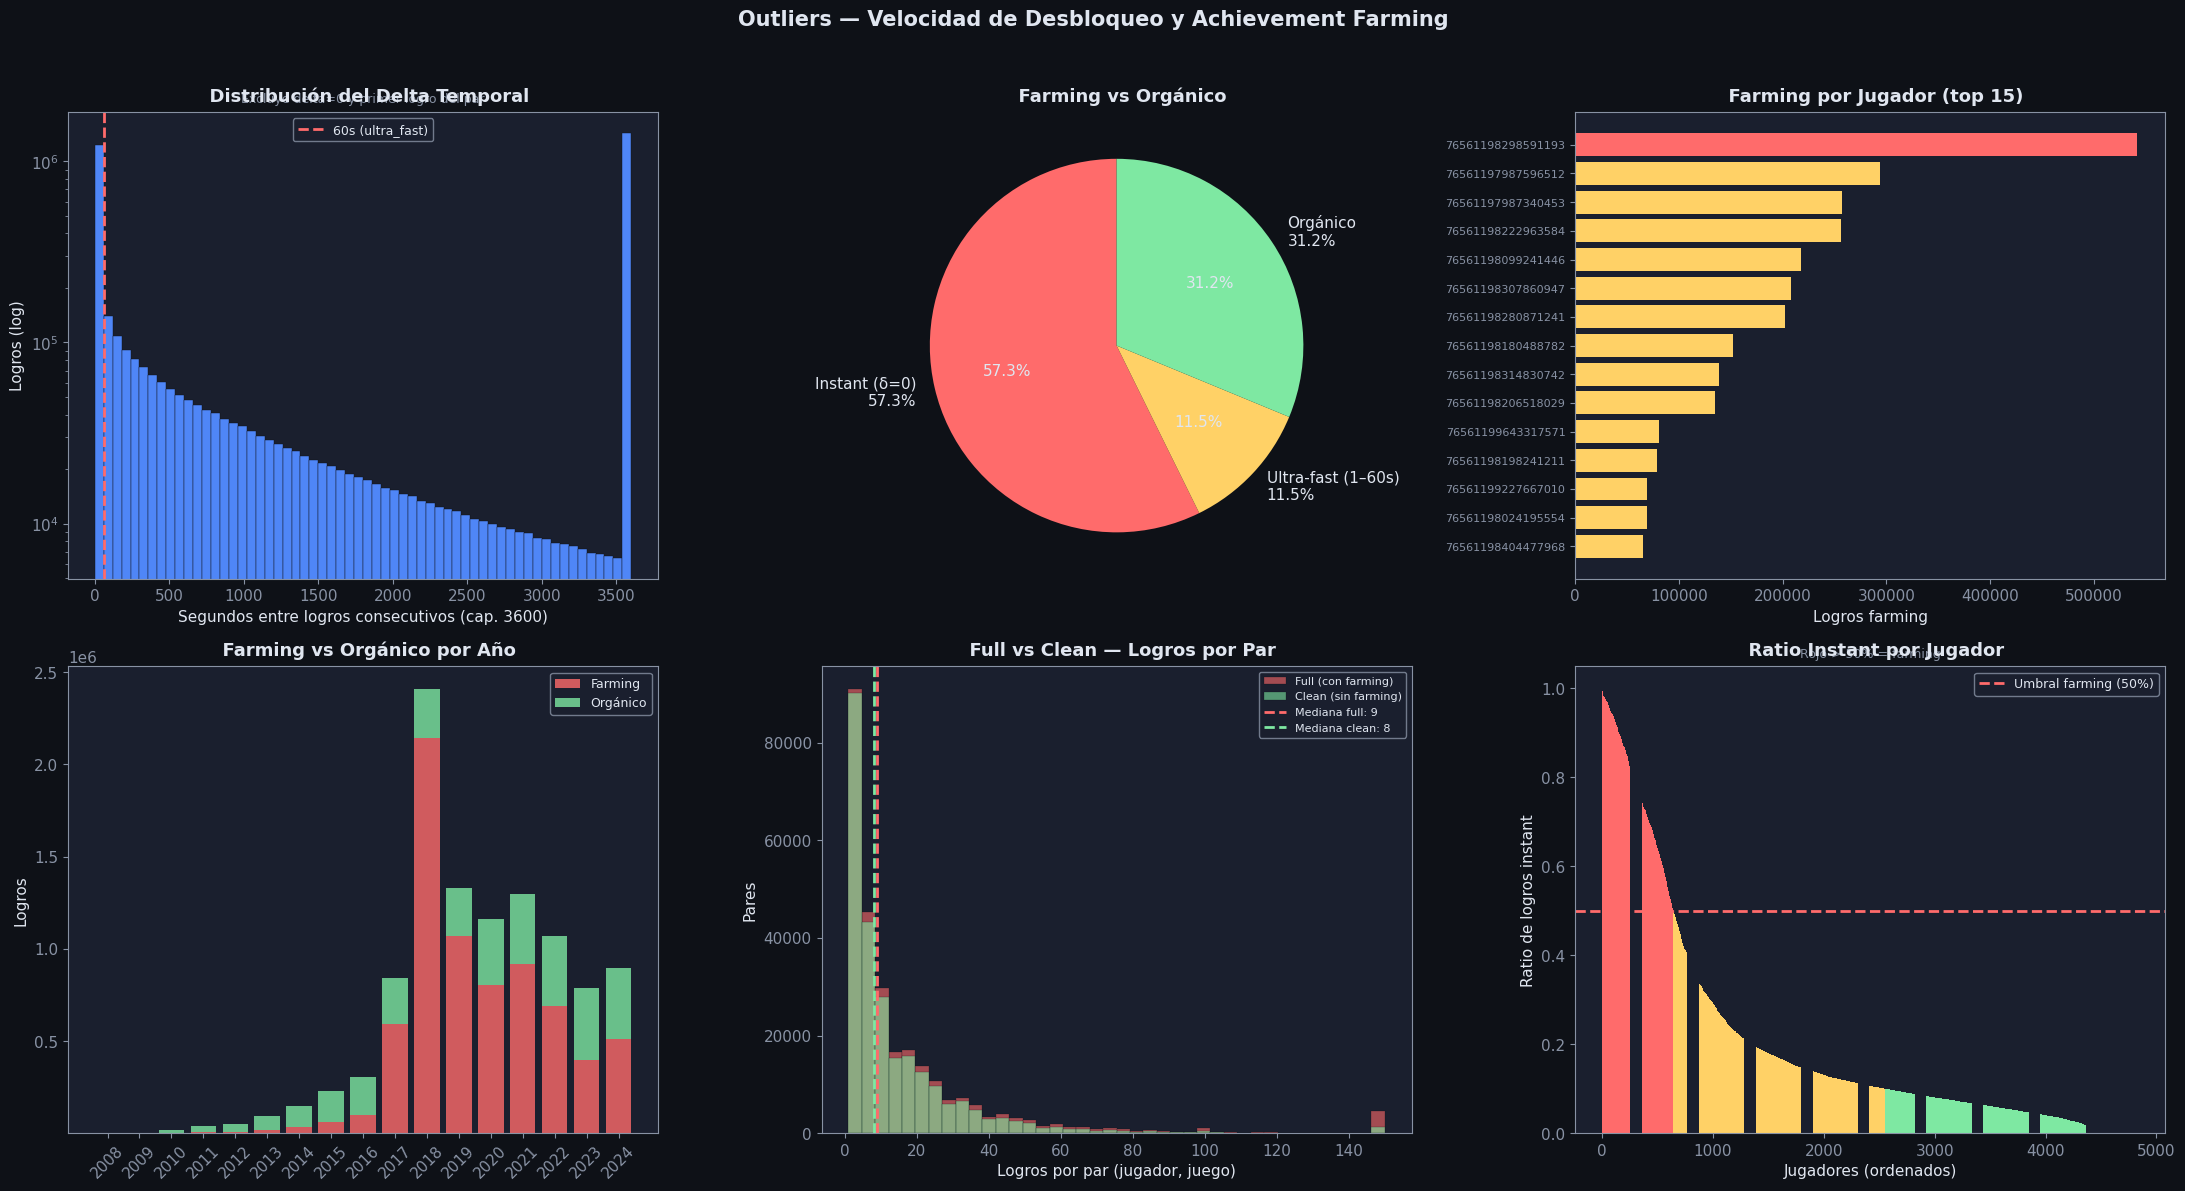

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.patch.set_facecolor(DARK_BG)
fig.suptitle('Outliers — Velocidad de Desbloqueo y Achievement Farming', fontsize=15,
             fontweight='bold', color=TEXT, y=0.99)

ax = axes[0, 0]
delta_valid = df_sorted['delta_sec'].dropna()
delta_nonzero = delta_valid[delta_valid > 0].clip(upper=3600)  # hasta 1 hora
ax.hist(delta_nonzero, bins=60, color=ACCENT1, edgecolor=DARK_BG, linewidth=0.3, log=True)
ax.axvline(60, color=ACCENT3, linewidth=2, linestyle='--', label='60s (ultra_fast)')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Segundos entre logros consecutivos (cap. 3600)'); ax.set_ylabel('Logros (log)')
title_ax(ax, '  Distribución del Delta Temporal', 'Excluye delta=0 y primer logro del par')

ax = axes[0, 1]
organic = n_total - n_farming
ax.pie([n_instant, n_ultra_fast, organic],
       labels=[f'Instant (δ=0)\n{n_instant/n_total*100:.1f}%',
               f'Ultra-fast (1–60s)\n{n_ultra_fast/n_total*100:.1f}%',
               f'Orgánico\n{organic/n_total*100:.1f}%'],
       colors=[ACCENT3, ACCENT4, ACCENT2], startangle=90,
       textprops={'color': TEXT}, autopct='%1.1f%%')
title_ax(ax, '  Farming vs Orgánico')


ax = axes[0, 2]
farming_by_player_plot = farming_by_player.head(15)
colors_fp = [ACCENT3 if v == farming_by_player.max() else ACCENT4 for v in farming_by_player_plot.values]
ax.barh(range(len(farming_by_player_plot)),
        farming_by_player_plot.values[::-1], color=colors_fp[::-1])
ax.set_yticks(range(len(farming_by_player_plot)))
ax.set_yticklabels([str(p) for p in farming_by_player_plot.index[::-1]], fontsize=8)
ax.set_xlabel('Logros farming')
title_ax(ax, '  Farming por Jugador (top 15)')

ax = axes[1, 0]
by_year_farm = df_sorted[df_sorted['is_farming']].groupby('year').size()
by_year_org  = df_sorted[~df_sorted['is_farming']].groupby('year').size()
years = sorted(set(by_year_farm.index) | set(by_year_org.index))
farm_vals = [by_year_farm.get(y, 0) for y in years]
org_vals  = [by_year_org.get(y, 0) for y in years]
x = range(len(years))
ax.bar(x, farm_vals, label='Farming', color=ACCENT3, alpha=0.8)
ax.bar(x, org_vals, bottom=farm_vals, label='Orgánico', color=ACCENT2, alpha=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels([str(y) for y in years], rotation=45)
ax.set_ylabel('Logros'); ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Farming vs Orgánico por Año')

ax = axes[1, 1]
per_pg_full  = df_sorted.groupby(['playerid','gameid']).size()
per_pg_clean = df_clean.groupby(['playerid','gameid']).size()
ax.hist(per_pg_full.clip(upper=150), bins=40, color=ACCENT3, alpha=0.6,
        edgecolor=DARK_BG, linewidth=0.3, label='Full (con farming)')
ax.hist(per_pg_clean.clip(upper=150), bins=40, color=ACCENT2, alpha=0.6,
        edgecolor=DARK_BG, linewidth=0.3, label='Clean (sin farming)')
ax.axvline(per_pg_full.median(), color=ACCENT3, linewidth=2, linestyle='--',
           label=f'Mediana full: {per_pg_full.median():.0f}')
ax.axvline(per_pg_clean.median(), color=ACCENT2, linewidth=2, linestyle='--',
           label=f'Mediana clean: {per_pg_clean.median():.0f}')
ax.legend(fontsize=8, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
ax.set_xlabel('Logros por par (jugador, juego)'); ax.set_ylabel('Pares')
title_ax(ax, '  Full vs Clean — Logros por Par')

ax = axes[1, 2]
instant_ratio_player = df_sorted.groupby('playerid')['is_instant'].mean().sort_values(ascending=False)
colors_ir = [ACCENT3 if v > 0.5 else ACCENT4 if v > 0.1 else ACCENT2 for v in instant_ratio_player.values]
ax.bar(range(len(instant_ratio_player)), instant_ratio_player.values, color=colors_ir)
ax.axhline(0.5, color=ACCENT3, linewidth=2, linestyle='--', label='Umbral farming (50%)')
ax.set_xlabel('Jugadores (ordenados)'); ax.set_ylabel('Ratio de logros instant')
ax.legend(fontsize=9, facecolor=CARD_BG, edgecolor=MUTED, labelcolor=TEXT)
title_ax(ax, '  Ratio Instant por Jugador', 'Rojo > 50% = farming')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

---
##  Dataset limpio final

In [16]:

df_final = df_clean.copy()

print("═" * 58)
print("  RESUMEN DEL DATASET LIMPIO — history")
print("═" * 58)
print(f"  Filas originales           : {df_raw.shape[0]:>10,}")
print(f"  Eliminadas (NaN/fecha)     : {df_raw.shape[0] - len(df):>10,}")
print(f"  Filas totales procesadas   : {len(df_final):>10,}")
print(f"  Jugadores únicos           : {df_final['playerid'].nunique():>10,}")
print(f"  Juegos únicos              : {df_final['gameid'].nunique():>10,}")
print(f"  Pares únicos (jugador×juego): {df_final.groupby(['playerid','gameid']).ngroups:>9,}")
print(f"  Logros farming (is_farming): {df_final['is_farming'].sum():>10,}  ({df_final['is_farming'].mean()*100:.1f}%)")
print(f"  Filas dataset CLEAN        : {len(df_clean):>10,}  ({len(df_clean)/len(df_final)*100:.1f}%)")
print(f"  Rango temporal             :  {df_final['date_acquired'].min().date()} → {df_final['date_acquired'].max().date()}")
print("═" * 58)
print()
print("Columnas disponibles:")
print(df_final.dtypes)
df_final.head(3)

══════════════════════════════════════════════════════════
  RESUMEN DEL DATASET LIMPIO — history
══════════════════════════════════════════════════════════
  Filas originales           : 10,693,879
  Eliminadas (NaN/fecha)     :          0
  Filas totales procesadas   :  4,566,642
  Jugadores únicos           :      4,811
  Juegos únicos              :     12,760
  Pares únicos (jugador×juego):   253,610
  Logros farming (is_farming):  1,390,116  (30.4%)
  Filas dataset CLEAN        :  4,566,642  (100.0%)
  Rango temporal             :  2008-09-13 → 2024-12-15
══════════════════════════════════════════════════════════

Columnas disponibles:
playerid                    int64
achievementid              object
date_acquired      datetime64[ns]
gameid                      int64
year                        int32
month                       int32
hour                        int32
weekday                     int32
prev_date          datetime64[ns]
delta_sec                 float64
is_instant

,playerid,achievementid,date_acquired,gameid,year,month,hour,weekday,prev_date,delta_sec,is_instant,is_ultra_fast,is_farming,is_farming_game
10021065,76561197960272169,220_HL2_HIT_CANCOP_WITHCAN,2020-01-11 14:46:11,220,2020,1,14,5,NaT,NaN,False,False,False,False
10021066,76561197960272169,220_HL2_ESCAPE_APARTMENTRAID,2020-04-18 07:18:01,220,2020,4,7,5,2020-01-11 14:46:11,8440310.0,False,False,False,False
10021082,76561197960272169,240_WIN_ROUNDS_LOW,2017-12-12 18:59:33,240,2017,12,18,1,NaT,NaN,False,False,False,False


---
## Exportar dataset limpio


**Archivos generados:**
- `history_clean.csv` — logros sin farming, con flags temporales: `gameid`, `year`, `month`, `hour`, `weekday`, `is_farming`, `is_farming_game`
- `history_per_pair.csv` — una fila por `(playerid, gameid)`: `n_logros_par` (target del modelo de regresión)


In [17]:

cols_hist = ['playerid','achievementid','gameid','date_acquired',
             'year','month','hour','weekday','is_farming','is_farming_game']
df_final[cols_hist].to_csv('Datos/history_clean.csv', index=False)

df_target = df_final[~df_final['is_farming_game']]
n_logros_par = (
    df_target
    .groupby(['playerid','gameid'])
    .size()
    .rename('n_logros_par')
    .reset_index()
)
n_logros_par.to_csv('Datos/history_per_pair.csv', index=False)

print(f'history_clean.csv   : {len(df_final):,} filas')
print(f'history_per_pair.csv: {len(n_logros_par):,} pares (playerid, gameid)')
print(f'  Target n_logros_par — median={n_logros_par["n_logros_par"].median():.0f}, max={n_logros_par["n_logros_par"].max()}')
n_logros_par.head(3)


history_clean.csv   : 4,566,642 filas
history_per_pair.csv: 253,610 pares (playerid, gameid)
  Target n_logros_par — median=8, max=5000


,playerid,gameid,n_logros_par
0,76561197960272169,220,2
1,76561197960272169,240,15
2,76561197960272169,300,5


---
##  Conclusiones


### Próximos pasos
- **Target de regresión:** usar `df_clean` (sin farming) y calcular `n_logros_par = logros desbloqueados por (playerid, gameid)`.
- **Normalizar con `achievements`:** calcular `completion_rate = n_logros_par / n_logros_totales_del_juego`. **Antes de este cruce, filtrar `is_spam_game = True` en `achievements`** — los juegos spam distorsionan completamente el completion_rate al hacer que cualquier usuario que los complete tenga un ratio artificialmente alto.
- **Feature de clasificación:** calcular `avg_completion_rate` por juego (promedio sobre todos sus jugadores) como señal de enganche del juego.
- **Cruzar con `players`:** agregar `country`, `created` (antigüedad de cuenta) como features del usuario.
- **Cruzar con `friends`:** agregar `n_friends_log` y `social_tier` para enriquecer el perfil de usuario.